In [1]:
import sys
sys.path.append("../src")

import numpy as np
import pandas as pd
import joblib
import ast
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr

from custom_transformers import ResumeFeatureBuilder, TextSimilarityVectorizer

pipeline = joblib.load("../data/processed/full_pipeline.pkl")
print("Pipeline loaded.")

Pipeline loaded.


In [5]:
ext_df = pd.read_csv("hf://datasets/batuhanmtl/job_resume_fit/job_resume_fit.csv")

print(ext_df.shape)
ext_df.head(2)

(2385, 10)


,ID,resume_text,job_text,category,job_required_skills,resume_skill_list,ai_matched_skills,ai_match_score,skill_string_match_score,fuzzy_match_score
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,Human Resources Business Partner\n------------...,HR,"['human resources management', 'talent acquisi...","['customer service', 'team management', 'marke...","['human resources management', 'employee relat...",49.40,12.50,63.24
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...",Human Resources Business Partner\n------------...,HR,"['human resources management', 'talent acquisi...","['adobe photoshop', 'adp', 'asset management',...","['human resources management', 'talent acquisi...",77.64,16.67,59.07


In [6]:
def to_python_list_str(x):
    """The resume_skill_list / job_required_skills columns are lists
    stringified as Python lists — reformat them to match the expected format
    expected by our parse_skills_set (ast.literal_eval)."""
    try:
        items = ast.literal_eval(x)
        return str(items)  # format as a valid Python repr
    except Exception:
        return "[]"

def to_newline_str(x):
    """job_required_skills → expected 'skills_required' format: one skill
    per line, separated by \\n (as in the original dataset)."""
    try:
        items = ast.literal_eval(x)
        return "\n".join(str(i) for i in items)
    except Exception:
        return np.nan


mapped_df = pd.DataFrame({
    "career_objective": ext_df["resume_text"],
    "skills": ext_df["resume_skill_list"].apply(to_python_list_str),
    "job_position_name": ext_df["category"],
    "skills_required": ext_df["job_required_skills"].apply(to_newline_str),
    "responsibilities.1": ext_df["job_text"],
    # Fields unavailable in this external dataset → NaN, handled natively by the pipeline
    "certification_providers": np.nan,
    "languages": np.nan,
    "extra_curricular_activity_types": np.nan,
    "educationaL_requirements": np.nan,
    "experiencere_requirement": np.nan,
    "age_requirement": np.nan,
})

mapped_df.head(2)

,career_objective,skills,job_position_name,skills_required,responsibilities.1,certification_providers,languages,extra_curricular_activity_types,educationaL_requirements,experiencere_requirement,age_requirement
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"['customer service', 'team management', 'marke...",HR,human resources management\ntalent acquisition...,Human Resources Business Partner\n------------...,NaN,NaN,NaN,NaN,NaN,NaN
1,"HR SPECIALIST, US HR OPERATIONS ...","['adobe photoshop', 'adp', 'asset management',...",HR,human resources management\ntalent acquisition...,Human Resources Business Partner\n------------...,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
predicted_scores = pipeline.predict(mapped_df)

ext_df["predicted_score"] = predicted_scores
ext_df["predicted_score_pct"] = predicted_scores * 100  # rescaled to 0-100 for comparison

print(ext_df[["predicted_score", "ai_match_score", "skill_string_match_score", "fuzzy_match_score"]].describe())

       predicted_score  ai_match_score  skill_string_match_score  \
count      2385.000000     2385.000000                2385.00000   
mean          0.746377       44.035862                  11.55426   
std           0.017616       24.628549                   7.48703   
min           0.656520        0.000000                   0.00000   
25%           0.736345       22.230000                   6.06000   
50%           0.747566       40.650000                  10.00000   
75%           0.758659       63.950000                  15.79000   
max           0.791464      100.000000                  41.67000   

       fuzzy_match_score  
count        2385.000000  
mean           56.579698  
std             6.778110  
min            26.150000  
25%            52.030000  
50%            56.400000  
75%            61.070000  
max            84.410000  


In [8]:
comparisons = ["ai_match_score", "skill_string_match_score", "fuzzy_match_score"]

print("Correlations between predicted_score and each external score:\n")
for col in comparisons:
    valid = ext_df[["predicted_score", col]].dropna()
    pearson_r, _ = pearsonr(valid["predicted_score"], valid[col])
    spearman_r, _ = spearmanr(valid["predicted_score"], valid[col])
    print(f"{col:30s} Pearson r = {pearson_r:.3f} | Spearman ρ = {spearman_r:.3f}")

Correlations between predicted_score and each external score:

ai_match_score                 Pearson r = 0.026 | Spearman ρ = 0.040
skill_string_match_score       Pearson r = 0.017 | Spearman ρ = 0.021
fuzzy_match_score              Pearson r = 0.098 | Spearman ρ = 0.078


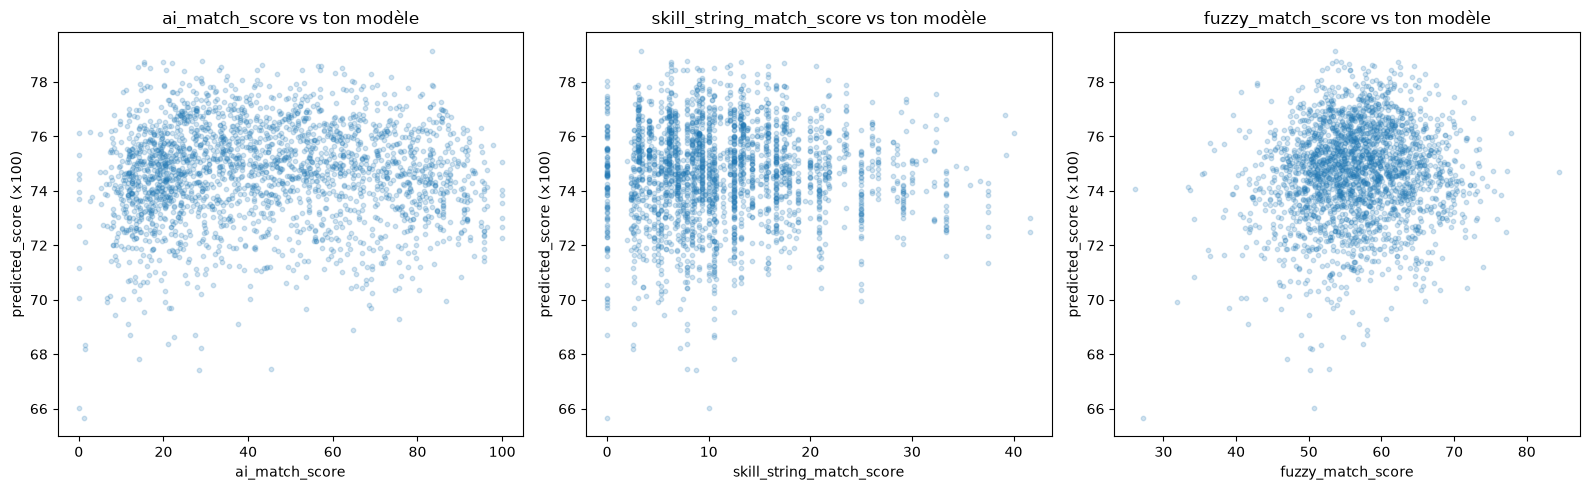

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, comparisons):
    ax.scatter(ext_df[col], ext_df["predicted_score_pct"], alpha=0.2, s=10)
    ax.set_xlabel(col)
    ax.set_ylabel("predicted_score (×100)")
    ax.set_title(f"{col} vs your model")

plt.tight_layout()
plt.show()

In [10]:
def compute_skills_overlap(row):
    try:
        resume_skills = set(s.strip().lower() for s in ast.literal_eval(row["resume_skill_list"]))
        job_skills = set(s.strip().lower() for s in ast.literal_eval(row["job_required_skills"]))
        return len(resume_skills & job_skills)
    except Exception:
        return 0

ext_df["skills_overlap_recomputed"] = ext_df.apply(compute_skills_overlap, axis=1)

valid = ext_df[["skills_overlap_recomputed", "skill_string_match_score"]].dropna()
r, _ = spearmanr(valid["skills_overlap_recomputed"], valid["skill_string_match_score"])
print(f"Correlation of skills_overlap (ours) vs skill_string_match_score (theirs) : ρ = {r:.3f}")

Correlation of skills_overlap (ours) vs skill_string_match_score (theirs) : ρ = 0.953
